# Model Experiment — XGBoost


## Section 1 — Imports & Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json
import os
import wandb
from sklearn.feature_selection import mutual_info_regression, f_regression
from sklearn.ensemble import RandomForestRegressor

from google.colab import drive
drive.mount('/content/drive')

pd.set_option('display.max_columns', 100)
np.random.seed(42)

Mounted at /content/drive


## Section 2 — Load Cleaned Data

In [2]:
path = '/content/drive/MyDrive/ML-final/data/processed/'

df = pd.read_csv(path + 'walmart_cleaned.csv')
df['Date'] = pd.to_datetime(df['Date'])

markdown_cols = ['MarkDown1', 'MarkDown2', 'MarkDown3', 'MarkDown4', 'MarkDown5']

print("Loaded cleaned data:", df.shape)
print(df.isnull().sum().sum(), "missing values remaining")

Loaded cleaned data: (421570, 16)
0 missing values remaining


## Section 3 — Wandb Login

In [3]:
wandb.login()

/usr/local/lib/python3.12/dist-packages/notebook/notebookapp.py:191: SyntaxWarning: invalid escape sequence '\/'
  | |_| | '_ \/ _` / _` |  _/ -_)
wandb: (1) Create a W&B account
wandb: (2) Use an existing W&B account
wandb: (3) Don't visualize my results


wandb: Enter your choice: 2


wandb: You chose 'Use an existing W&B account'
wandb: Logging into https://api.wandb.ai. (Learn how to deploy a W&B server locally: https://wandb.me/wandb-server)
wandb: Create a new API key at: https://wandb.ai/authorize?ref=models
wandb: Store your API key securely and do not share it.


wandb: Paste your API key and hit enter: ··········


wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: gormo22 (gormo22-free-university-of-tbilisi-) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


True

## Section 4 — Confirm Clean Data (`XGBoost_Cleaning`)

In [4]:
run = wandb.init(project="walmart-sales-forecasting", group="XGBoost_Training",
                  name="XGBoost_Cleaning", job_type="preprocessing")

wandb.log({
    "rows": df.shape[0],
    "cols": df.shape[1],
    "missing_values_total": int(df.isnull().sum().sum()),
})
wandb.config.update({"source_file": "walmart_cleaned.csv (produced by Data_Overview.ipynb)"})

wandb.finish()
print("XGBoost_Cleaning run finished")

cols,▁
missing_values_total,▁
rows,▁
cols,16
missing_values_total,0
rows,421570


XGBoost_Cleaning run finished


## Section 5 — Feature Engineering (`XGBoost_Feature_Engineering`)

In [5]:
run = wandb.init(project="walmart-sales-forecasting", group="XGBoost_Training",
                  name="XGBoost_Feature_Engineering", job_type="feature-engineering")

df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month
df['Week'] = df['Date'].dt.isocalendar().week.astype(int)
df['Day'] = df['Date'].dt.day

type_mapping = {'A': 3, 'B': 2, 'C': 1}
df['Type'] = df['Type'].map(type_mapping)
df['IsHoliday'] = df['IsHoliday'].astype(int)

df['Total_Markdown'] = df[markdown_cols].sum(axis=1)
df['Has_Markdown'] = (df['Total_Markdown'] > 0).astype(int)
df['Markdown_Count'] = (df[markdown_cols] > 0).sum(axis=1)

holiday_dates = {
    'Is_SuperBowl':    pd.to_datetime(['2010-02-12', '2011-02-11', '2012-02-10', '2013-02-08']),
    'Is_LaborDay':     pd.to_datetime(['2010-09-10', '2011-09-09', '2012-09-07', '2013-09-06']),
    'Is_Thanksgiving': pd.to_datetime(['2010-11-26', '2011-11-25', '2012-11-23', '2013-11-29']),
    'Is_Christmas':    pd.to_datetime(['2010-12-31', '2011-12-30', '2012-12-28', '2013-12-27']),
}
for col, dates in holiday_dates.items():
    df[col] = df['Date'].isin(dates).astype(int)

print("Calendar + markdown + holiday features added.")

df = df.sort_values(['Store', 'Dept', 'Date']).reset_index(drop=True)
grp = df.groupby(['Store', 'Dept'])['Weekly_Sales']

df['Sales_Lag1']      = grp.shift(1)
df['Sales_Lag2']      = grp.shift(2)
df['Sales_Lag3']      = grp.shift(3)
df['Sales_Lag52']     = grp.shift(52)
df['Sales_RollMean4'] = grp.transform(lambda s: s.shift(1).rolling(4).mean())
df['Sales_RollStd4']  = grp.transform(lambda s: s.shift(1).rolling(4).std())

lag_na = df[['Sales_Lag1', 'Sales_Lag2', 'Sales_Lag3', 'Sales_Lag52',
             'Sales_RollMean4', 'Sales_RollStd4']].isna().sum()
print("NA in lag/rolling features (expected at each series' start; XGBoost handles NaN natively):")
print(lag_na)

Calendar + markdown + holiday features added.
NA in lag/rolling features (expected at each series' start; XGBoost handles NaN natively):
Sales_Lag1           3331
Sales_Lag2           6625
Sales_Lag3           9889
Sales_Lag52        160487
Sales_RollMean4     13134
Sales_RollStd4      13134
dtype: int64


In [6]:
def compute_best_partner(data):
    pivot = data.pivot_table(index='Date', columns='Dept', values='Weekly_Sales', aggfunc='mean')
    corr = pivot.corr().to_numpy().copy()
    dept_ids = pivot.columns.to_numpy()
    np.fill_diagonal(corr, -np.inf)
    return {dept_ids[i]: dept_ids[np.argmax(corr[i])] for i in range(len(dept_ids))}

def compute_avg_maps(data):
    dept_avg = data.groupby('Dept')['Weekly_Sales'].mean().to_dict()
    store_avg = data.groupby('Store')['Weekly_Sales'].mean().to_dict()
    overall_avg = data['Weekly_Sales'].mean()
    return dept_avg, store_avg, overall_avg

best_partner = compute_best_partner(df)
df['Partner_Dept'] = df['Dept'].map(best_partner)

lag1_lookup = df[['Store', 'Dept', 'Date', 'Sales_Lag1']].rename(
    columns={'Dept': 'Partner_Dept', 'Sales_Lag1': 'Partner_Dept_Sales_Lag1'})
df = pd.merge(df, lag1_lookup, on=['Store', 'Partner_Dept', 'Date'], how='left')

dept_avg_map, store_avg_map, overall_mean_sales = compute_avg_maps(df)
df['Dept_Avg_Sales']  = df['Dept'].map(dept_avg_map)
df['Store_Avg_Sales'] = df['Store'].map(store_avg_map)

print("Partner_Dept_Sales_Lag1 NA:", df['Partner_Dept_Sales_Lag1'].isna().sum(), "/", len(df))
print("Corr(Weekly_Sales, Partner_Dept_Sales_Lag1):",
      df[['Weekly_Sales', 'Partner_Dept_Sales_Lag1']].corr().iloc[0, 1])

wandb.log({
    "na_Sales_Lag1": int(lag_na['Sales_Lag1']),
    "na_Sales_Lag52": int(lag_na['Sales_Lag52']),
    "na_Partner_Dept_Sales_Lag1": int(df['Partner_Dept_Sales_Lag1'].isna().sum()),
})
wandb.config.update({
    "lag_feature_na_strategy": "left_as_NaN_xgboost_native_handling",
    "cross_dept_feature_source": "best_positive_correlation_partner_dept_lag1",
    "leakage_note": "avg/partner maps fit on full df for now; must refit per-fold once CV is added",
})

os.makedirs('/content/lookup_maps', exist_ok=True)
with open('/content/lookup_maps/dept_avg_map.json', 'w') as f:
    json.dump({str(k): v for k, v in dept_avg_map.items()}, f)
with open('/content/lookup_maps/store_avg_map.json', 'w') as f:
    json.dump({str(k): v for k, v in store_avg_map.items()}, f)
with open('/content/lookup_maps/best_partner_map.json', 'w') as f:
    json.dump({str(k): int(v) for k, v in best_partner.items()}, f)
with open('/content/lookup_maps/overall_mean_sales.json', 'w') as f:
    json.dump({"overall_mean_sales": overall_mean_sales}, f)

lookup_artifact = wandb.Artifact(name="train_only_lookup_tables", type="preprocessing-maps",
                                  description="Dept/Store avg sales + best-partner-dept map")
for fname in ["dept_avg_map.json", "store_avg_map.json", "best_partner_map.json", "overall_mean_sales.json"]:
    lookup_artifact.add_file(f"/content/lookup_maps/{fname}")
wandb.run.log_artifact(lookup_artifact)

wandb.finish()
print("XGBoost_Feature_Engineering run finished")

Partner_Dept_Sales_Lag1 NA: 26496 / 421570
Corr(Weekly_Sales, Partner_Dept_Sales_Lag1): 0.4681778403866166


wandb: WARNING Artifact "train_only_lookup_tables" already exists with the same content. No new version will be created.


na_Partner_Dept_Sales_Lag1,▁
na_Sales_Lag1,▁
na_Sales_Lag52,▁
na_Partner_Dept_Sales_Lag1,26496
na_Sales_Lag1,3331
na_Sales_Lag52,160487


XGBoost_Feature_Engineering run finished


## Section 6 — Feature Selection (`XGBoost_Feature_Selection`)

Top 15 selected features: ['Sales_Lag1', 'Sales_Lag52', 'Sales_RollMean4', 'Sales_Lag2', 'Sales_Lag3', 'Sales_RollStd4', 'Dept_Avg_Sales', 'Store_Avg_Sales', 'Size', 'Partner_Dept_Sales_Lag1', 'MarkDown5', 'Total_Markdown', 'Unemployment', 'MarkDown3', 'Type']
Total candidate features considered: 32
Features selected (top 15 by average rank): 15
Selected features: ['Sales_Lag1', 'Sales_Lag52', 'Sales_RollMean4', 'Sales_Lag2', 'Sales_Lag3', 'Sales_RollStd4', 'Dept_Avg_Sales', 'Store_Avg_Sales', 'Size', 'Partner_Dept_Sales_Lag1', 'MarkDown5', 'Total_Markdown', 'Unemployment', 'MarkDown3', 'Type']


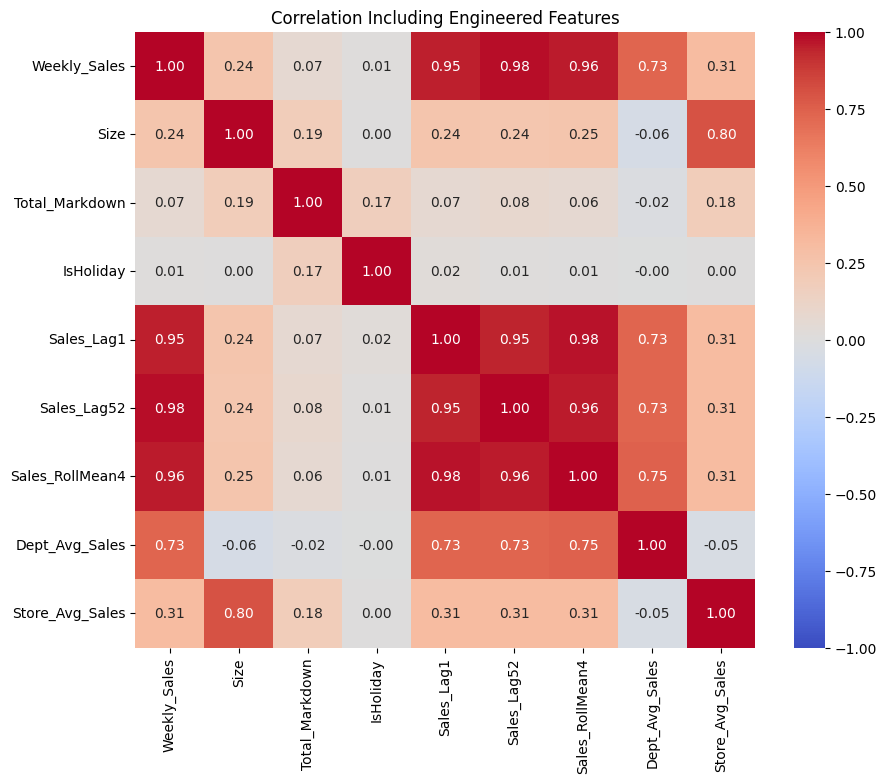

XGBoost_Feature_Selection run finished


In [7]:
run = wandb.init(project="walmart-sales-forecasting", group="XGBoost_Training",
                  name="XGBoost_Feature_Selection", job_type="feature-selection")

exclude_cols = ['Weekly_Sales', 'Date', 'Store', 'Dept', 'Partner_Dept']
candidate_features = [c for c in df.columns if c not in exclude_cols and df[c].dtype != 'object']

fs_df = df[candidate_features + ['Weekly_Sales']].dropna()
fs_sample = fs_df.sample(n=min(50000, len(fs_df)), random_state=42)
X = fs_sample[candidate_features]
y = fs_sample['Weekly_Sales']

f_scores, _ = f_regression(X, y)
mi_scores = mutual_info_regression(X, y, random_state=42)

rf = RandomForestRegressor(n_estimators=100, max_depth=8, n_jobs=-1, random_state=42)
rf.fit(X, y)

selection_df = pd.DataFrame({
    'F_test_rank': pd.Series(f_scores, index=candidate_features).rank(ascending=False),
    'MI_rank': pd.Series(mi_scores, index=candidate_features).rank(ascending=False),
    'RF_rank': pd.Series(rf.feature_importances_, index=candidate_features).rank(ascending=False),
})
selection_df['avg_rank'] = selection_df.mean(axis=1)
selection_df = selection_df.sort_values('avg_rank')

wandb.log({"Feature_Selection_Scores": wandb.Table(
    dataframe=selection_df.reset_index().rename(columns={'index': 'feature'}))})

selected_features = selection_df.head(15).index.tolist()
print("Top 15 selected features:", selected_features)
print(f"Total candidate features considered: {len(candidate_features)}")
print(f"Features selected (top 15 by average rank): {len(selected_features)}")
print(f"Selected features: {selected_features}")
wandb.config.update({"selected_features": selected_features})

corr_cols = ['Weekly_Sales', 'Size', 'Total_Markdown', 'IsHoliday',
             'Sales_Lag1', 'Sales_Lag52', 'Sales_RollMean4',
             'Dept_Avg_Sales', 'Store_Avg_Sales']
plt.figure(figsize=(10, 8))
sns.heatmap(df[corr_cols].corr(), annot=True, fmt='.2f', cmap='coolwarm', vmin=-1, vmax=1)
plt.title("Correlation Including Engineered Features")
wandb.log({"Engineered_Feature_Correlations": wandb.Image(plt)})
plt.show()
plt.close()

wandb.finish()
print("XGBoost_Feature_Selection run finished")

## Section 7 — Save Engineered Dataset

In [8]:
out_dir = '/content/drive/MyDrive/ML-final/data/processed/'
os.makedirs(out_dir, exist_ok=True)
out_path = out_dir + 'walmart_engineered_xgboost.csv'
df.to_csv(out_path, index=False)

run = wandb.init(project="walmart-sales-forecasting", group="XGBoost_Training",
                  name="XGBoost_Save_Engineered_Data", job_type="dataset-export")

artifact = wandb.Artifact(name="engineered_walmart_data_xgboost", type="dataset",
                           description="Cleaned + XGBoost-specific engineered features")
artifact.add_file(out_path)
wandb.run.log_artifact(artifact)
wandb.config.update({"n_rows": df.shape[0], "n_cols": df.shape[1]})

wandb.finish()
print(f"Saved engineered data: {df.shape} -> {out_path}")

wandb: WARNING Artifact "engineered_walmart_data_xgboost" already exists with the same content. No new version will be created.


Saved engineered data: (421570, 37) -> /content/drive/MyDrive/ML-final/data/processed/walmart_engineered_xgboost.csv


Named `walmart_engineered_xgboost.csv` (not just `walmart_engineered.csv`) on purpose — other model notebooks (LightGBM, N-BEATS, etc.) may engineer a different feature set, and a model-specific filename avoids one notebook silently overwriting another's output.

## Section 8 — Preprocessing Pipeline (for inference)

In [9]:
class XGBoostPreprocessingPipeline:
    """Wraps cleaning + feature engineering so the exact same transform can be
    applied to test.csv at inference time. Lookup maps (dept/store averages,
    best partner dept) are fit once on training data and passed in here --
    they must NOT be recomputed on test data."""

    def __init__(self, dept_avg_map, store_avg_map, best_partner, overall_mean_sales,
                 markdown_cols, train_history):
        self.dept_avg_map = dept_avg_map
        self.store_avg_map = store_avg_map
        self.best_partner = best_partner
        self.overall_mean_sales = overall_mean_sales
        self.markdown_cols = markdown_cols
        self.train_history = train_history[['Store', 'Dept', 'Date', 'Weekly_Sales']].copy()

        self.holiday_dates = {
            'Is_SuperBowl':    pd.to_datetime(['2010-02-12', '2011-02-11', '2012-02-10', '2013-02-08']),
            'Is_LaborDay':     pd.to_datetime(['2010-09-10', '2011-09-09', '2012-09-07', '2013-09-06']),
            'Is_Thanksgiving': pd.to_datetime(['2010-11-26', '2011-11-25', '2012-11-23', '2013-11-29']),
            'Is_Christmas':    pd.to_datetime(['2010-12-31', '2011-12-30', '2012-12-28', '2013-12-27']),
        }

    def transform(self, raw_df, stores_df, features_df):
        data = pd.merge(raw_df, stores_df, on='Store', how='left')
        data = pd.merge(data, features_df, on=['Store', 'Date', 'IsHoliday'], how='left')
        data['Date'] = pd.to_datetime(data['Date'])
        has_target = 'Weekly_Sales' in data.columns

        data[self.markdown_cols] = data[self.markdown_cols].fillna(0)
        data = data.sort_values(['Store', 'Date']).reset_index(drop=True)
        data['CPI'] = data.groupby('Store')['CPI'].transform(lambda s: s.ffill().bfill())
        data['Unemployment'] = data.groupby('Store')['Unemployment'].transform(lambda s: s.ffill().bfill())

        data['Year'] = data['Date'].dt.year
        data['Month'] = data['Date'].dt.month
        data['Week'] = data['Date'].dt.isocalendar().week.astype(int)
        data['Day'] = data['Date'].dt.day
        data['Type'] = data['Type'].map({'A': 3, 'B': 2, 'C': 1})
        data['IsHoliday'] = data['IsHoliday'].astype(int)

        data['Total_Markdown'] = data[self.markdown_cols].sum(axis=1)
        data['Has_Markdown'] = (data['Total_Markdown'] > 0).astype(int)
        data['Markdown_Count'] = (data[self.markdown_cols] > 0).sum(axis=1)

        for col, dates in self.holiday_dates.items():
            data[col] = data['Date'].isin(dates).astype(int)

        if not has_target:
            data['Weekly_Sales'] = np.nan

        data['_is_target_row'] = True
        history = self.train_history.copy()
        history['_is_target_row'] = False

        combined = pd.concat([history, data], ignore_index=True, sort=False)
        combined = combined.sort_values(['Store', 'Dept', 'Date', '_is_target_row'])
        combined = combined.drop_duplicates(subset=['Store', 'Dept', 'Date'], keep='last').reset_index(drop=True)
        combined = combined.sort_values(['Store', 'Dept', 'Date']).reset_index(drop=True)

        grp = combined.groupby(['Store', 'Dept'])['Weekly_Sales']
        combined['Sales_Lag1']      = grp.shift(1)
        combined['Sales_Lag2']      = grp.shift(2)
        combined['Sales_Lag3']      = grp.shift(3)
        combined['Sales_Lag52']     = grp.shift(52)
        combined['Sales_RollMean4'] = grp.transform(lambda s: s.shift(1).rolling(4).mean())
        combined['Sales_RollStd4']  = grp.transform(lambda s: s.shift(1).rolling(4).std())

        combined['Partner_Dept'] = combined['Dept'].map(self.best_partner)
        lag1_lookup = combined[['Store', 'Dept', 'Date', 'Sales_Lag1']].rename(
            columns={'Dept': 'Partner_Dept', 'Sales_Lag1': 'Partner_Dept_Sales_Lag1'})
        combined = pd.merge(combined, lag1_lookup, on=['Store', 'Partner_Dept', 'Date'], how='left')

        result = combined[combined['_is_target_row']].drop(columns=['_is_target_row']).reset_index(drop=True)
        if not has_target:
            result = result.drop(columns=['Weekly_Sales'])

        result['Dept_Avg_Sales']  = result['Dept'].map(self.dept_avg_map).fillna(self.overall_mean_sales)
        result['Store_Avg_Sales'] = result['Store'].map(self.store_avg_map).fillna(self.overall_mean_sales)

        return result

preprocessing_pipeline = XGBoostPreprocessingPipeline(
    dept_avg_map=dept_avg_map,
    store_avg_map=store_avg_map,
    best_partner=best_partner,
    overall_mean_sales=overall_mean_sales,
    markdown_cols=markdown_cols,
    train_history=df,
)

print("Preprocessing pipeline built with corrected transform method.")

Preprocessing pipeline built with corrected transform method.


## Section 9 — Walk-Forward Cross-Validation Setup

In [10]:
import xgboost as xgb

def weighted_mae(y_true, y_pred, weights):
    return np.sum(weights * np.abs(y_true - y_pred)) / np.sum(weights)


def refit_fold_features(train_fold, val_fold):
    """Leakage-safe refit of dept/store average sales, best-partner-dept mapping,
    and the Partner_Dept_Sales_Lag1 feature, using ONLY the fold's training window.
    Must be called fresh for every fold/split -- never reuse maps fit on a different
    window. This is the same idea as Section 10's original single-split refit, just
    generalized so both CV folds and the final holdout split share one implementation."""
    train_fold = train_fold.copy()
    val_fold = val_fold.copy()

    best_partner_fold = compute_best_partner(train_fold)
    dept_avg_fold, store_avg_fold, overall_mean_fold = compute_avg_maps(train_fold)

    for split_df in (train_fold, val_fold):
        split_df['Dept_Avg_Sales']  = split_df['Dept'].map(dept_avg_fold).fillna(overall_mean_fold)
        split_df['Store_Avg_Sales'] = split_df['Store'].map(store_avg_fold).fillna(overall_mean_fold)
        split_df['Partner_Dept']    = split_df['Dept'].map(best_partner_fold)

    # Partner_Dept_Sales_Lag1 draws on each row's own causal Sales_Lag1 (already computed in
    # Section 5 using only that store/dept's own past weeks), so recomputing this lookup is
    # safe -- the leakage risk was only in WHICH dept counts as "partner", and that mapping
    # above is fit on the fold's training window only.
    lookup_source = pd.concat([train_fold, val_fold], ignore_index=True)[
        ['Store', 'Dept', 'Date', 'Sales_Lag1']
    ].rename(columns={'Dept': 'Partner_Dept', 'Sales_Lag1': 'Partner_Dept_Sales_Lag1'})

    train_fold = train_fold.drop(columns=['Partner_Dept_Sales_Lag1'], errors='ignore').merge(
        lookup_source, on=['Store', 'Partner_Dept', 'Date'], how='left')
    val_fold = val_fold.drop(columns=['Partner_Dept_Sales_Lag1'], errors='ignore').merge(
        lookup_source, on=['Store', 'Partner_Dept', 'Date'], how='left')

    return train_fold, val_fold


def make_walk_forward_folds(data, n_folds=4, val_frac=0.08):
    """Expanding-window walk-forward folds. Fold i trains on every week before cutoff_i
    and validates on the val_frac chunk of weeks immediately after it -- training history
    grows with each fold, validation windows never overlap and never precede their training
    data. This matches how the model will actually be used (predict weeks it hasn't seen yet)
    far better than a single random or single time-based split."""
    dates = np.sort(data['Date'].unique())
    n_dates = len(dates)
    val_size = max(1, int(n_dates * val_frac))

    first_cutoff_idx = n_dates - n_folds * val_size
    if first_cutoff_idx < int(n_dates * 0.3):
        raise ValueError("Not enough history for this many folds/val_frac -- reduce n_folds or val_frac")

    folds = []
    for i in range(n_folds):
        train_end_idx = first_cutoff_idx + i * val_size
        val_start_idx = train_end_idx
        val_end_idx   = train_end_idx + val_size

        train_dates = dates[:train_end_idx]
        val_dates   = dates[val_start_idx:val_end_idx]

        folds.append({
            "fold": i,
            "train_start": pd.Timestamp(train_dates.min()),
            "train_end":   pd.Timestamp(train_dates.max()),
            "val_start":   pd.Timestamp(val_dates.min()),
            "val_end":     pd.Timestamp(val_dates.max()),
        })
    return folds


cv_folds = make_walk_forward_folds(df, n_folds=4, val_frac=0.08)
for f in cv_folds:
    n_train_wks = (f['train_end'] - f['train_start']).days // 7 + 1
    n_val_wks   = (f['val_end']   - f['val_start']).days   // 7 + 1
    print(f"Fold {f['fold']}: train {f['train_start'].date()}..{f['train_end'].date()} "
          f"({n_train_wks} wks) -> val {f['val_start'].date()}..{f['val_end'].date()} ({n_val_wks} wks)")

# Materialize every fold's train/val dataframes ONCE with leakage-safe features, so every
# hyperparameter combo and every feature-count option in Sections 10, 13 and 15 is scored
# on exactly the same splits.
prepared_cv_folds = []
for f in cv_folds:
    train_fold = df[(df['Date'] >= f['train_start']) & (df['Date'] <= f['train_end'])].copy()
    val_fold   = df[(df['Date'] >= f['val_start'])   & (df['Date'] <= f['val_end'])].copy()
    train_fold, val_fold = refit_fold_features(train_fold, val_fold)
    prepared_cv_folds.append((train_fold, val_fold))

print(f"\nPrepared {len(prepared_cv_folds)} walk-forward folds for CV-based model/feature selection.")


Fold 0: train 2010-02-05..2011-12-23 (99 wks) -> val 2011-12-30..2012-03-09 (11 wks)
Fold 1: train 2010-02-05..2012-03-09 (110 wks) -> val 2012-03-16..2012-05-25 (11 wks)
Fold 2: train 2010-02-05..2012-05-25 (121 wks) -> val 2012-06-01..2012-08-10 (11 wks)
Fold 3: train 2010-02-05..2012-08-10 (132 wks) -> val 2012-08-17..2012-10-26 (11 wks)

Prepared 4 walk-forward folds for CV-based model/feature selection.


## Section 10 — Cross-Validation Diagnostic Run (`XGBoost_Cross_Validation`)

Before trusting any single train/val split, check how much validation WMAE actually varies across 4 rolling windows with a fixed baseline config. A wide spread here -- especially for folds that land on Thanksgiving/Christmas weeks -- is exactly the kind of thing a single 90/10 holdout can hide.

In [11]:
run = wandb.init(project="walmart-sales-forecasting", group="XGBoost_Training",
                  name="XGBoost_Cross_Validation", job_type="cross-validation")

baseline_params = {"max_depth": 8, "learning_rate": 0.05, "n_estimators": 1000}
cv_diag_rows = []

for fold_idx, (train_fold, val_fold) in enumerate(prepared_cv_folds):
    Xtr, ytr = train_fold[candidate_features], train_fold['Weekly_Sales']
    Xva, yva = val_fold[candidate_features],   val_fold['Weekly_Sales']
    wtr = np.where(train_fold['IsHoliday'] == 1, 5, 1)
    wva = np.where(val_fold['IsHoliday'] == 1, 5, 1)

    m = xgb.XGBRegressor(objective="reg:squarederror", subsample=0.8, colsample_bytree=0.8,
                          random_state=42, n_jobs=-1, tree_method="hist",
                          early_stopping_rounds=50, **baseline_params)
    m.fit(Xtr, ytr, sample_weight=wtr, eval_set=[(Xva, yva)], sample_weight_eval_set=[wva], verbose=False)

    wmae = weighted_mae(yva, m.predict(Xva), wva)
    f = cv_folds[fold_idx]
    cv_diag_rows.append({"fold": fold_idx, "val_wmae": wmae,
                          "val_start": str(f['val_start'].date()), "val_end": str(f['val_end'].date()),
                          "contains_holiday": bool(val_fold['IsHoliday'].max() == 1)})
    print(f"Fold {fold_idx} ({f['val_start'].date()} - {f['val_end'].date()}, "
          f"holiday={bool(val_fold['IsHoliday'].max() == 1)}): val_wmae={wmae:.2f}")

cv_diag_df = pd.DataFrame(cv_diag_rows)
wandb.log({"cv_folds_table": wandb.Table(dataframe=cv_diag_df)})
wandb.log({
    "cv_mean_wmae": cv_diag_df['val_wmae'].mean(),
    "cv_std_wmae":  cv_diag_df['val_wmae'].std(),
})
print(f"\nCV mean val_wmae (baseline params): {cv_diag_df['val_wmae'].mean():.2f} "
      f"+/- {cv_diag_df['val_wmae'].std():.2f}")
wandb.finish()


Fold 0 (2011-12-30 - 2012-03-09, holiday=True): val_wmae=1863.45
Fold 1 (2012-03-16 - 2012-05-25, holiday=False): val_wmae=1457.41
Fold 2 (2012-06-01 - 2012-08-10, holiday=False): val_wmae=1172.70
Fold 3 (2012-08-17 - 2012-10-26, holiday=True): val_wmae=1285.55

CV mean val_wmae (baseline params): 1444.78 +/- 302.67


cv_mean_wmae,▁
cv_std_wmae,▁
cv_mean_wmae,1444.7776
cv_std_wmae,302.66856


## Section 11 — Final Holdout Split (for Early Stopping & Reporting)

This single time-based split is kept for early-stopping during final training and for human-readable before/after metrics -- it is no longer the sole basis for model or feature-set decisions. Those decisions (hyperparameters, feature count) are now made using the walk-forward CV in Sections 9-10, which averages performance across 4 rolling validation windows instead of trusting a single 10% tail.

In [12]:
run = wandb.init(project="walmart-sales-forecasting", group="XGBoost_Training",
                  name="XGBoost_Train_Val_Split", job_type="split")

df = df.sort_values('Date').reset_index(drop=True)
cutoff_date = df['Date'].quantile(0.9, interpolation='nearest')  # last ~10% of weeks held out

train_df = df[df['Date'] <= cutoff_date].copy()
val_df   = df[df['Date']  > cutoff_date].copy()

print(f"Cutoff date: {cutoff_date}")
print(f"Train: {train_df.shape[0]} rows ({train_df['Date'].min()} to {train_df['Date'].max()})")
print(f"Val:   {val_df.shape[0]} rows ({val_df['Date'].min()} to {val_df['Date'].max()})")

wandb.log({"train_rows": train_df.shape[0], "val_rows": val_df.shape[0],
           "cutoff_date": str(cutoff_date)})
wandb.config.update({"split_strategy": "time_based_last_10pct_weeks"})
wandb.finish()

Cutoff date: 2012-07-20 00:00:00
Train: 380107 rows (2010-02-05 00:00:00 to 2012-07-20 00:00:00)
Val:   41463 rows (2012-07-27 00:00:00 to 2012-10-26 00:00:00)


train_rows,▁
val_rows,▁
cutoff_date,2012-07-20 00:00:00
train_rows,380107
val_rows,41463


## Section 12 — Refit Leakage-Safe Features on Holdout Split

Reuses the same `refit_fold_features()` helper defined for cross-validation (Section 9), so the holdout split is prepared identically to every CV fold -- one leakage-safe refit routine instead of two parallel implementations that could drift apart.

In [13]:
train_df, val_df = refit_fold_features(train_df, val_df)

print("Dept/Store averages + partner-dept map refit on training split only (no val leakage)")
print("(same refit_fold_features() routine used by every walk-forward CV fold in Section 9-10)")


Dept/Store averages + partner-dept map refit on training split only (no val leakage)
(same refit_fold_features() routine used by every walk-forward CV fold in Section 9-10)


## Section 13 — Hyperparameter Search (Walk-Forward CV Averaged)

In [14]:
feature_cols = selected_features  # from the feature selection step (Section 6)

X_train, y_train = train_df[feature_cols], train_df['Weekly_Sales']
X_val, y_val     = val_df[feature_cols],   val_df['Weekly_Sales']
w_train = np.where(train_df['IsHoliday'] == 1, 5, 1)
w_val   = np.where(val_df['IsHoliday'] == 1, 5, 1)

import random
random.seed(42)

param_space = {
    "max_depth":        [4, 6, 8, 10],
    "learning_rate":    [0.01, 0.03, 0.05, 0.1],
    "n_estimators":     [1000, 2000, 3000],
    "subsample":        [0.6, 0.8, 1.0],
    "colsample_bytree": [0.6, 0.8, 1.0],
    "min_child_weight": [1, 3, 5, 10],
    "reg_alpha":        [0.0, 0.1, 0.5, 1.0],
    "reg_lambda":       [1.0, 2.0, 5.0],
}

N_TRIALS = 20
seen = set()
param_grid = []
while len(param_grid) < N_TRIALS:
    combo = {k: random.choice(v) for k, v in param_space.items()}
    key = tuple(sorted(combo.items()))
    if key in seen:
        continue
    seen.add(key)
    param_grid.append(combo)

results = []
for i, params in enumerate(param_grid):
    run = wandb.init(project="walmart-sales-forecasting", group="XGBoost_Training",
                      name=f"XGBoost_HPO_trial_{i}", job_type="hyperparameter-search",
                      config={**params, "validation": "4-fold walk-forward CV"}, reinit=True)

    fold_wmaes, fold_best_iters = [], []
    for fold_idx, (train_fold, val_fold) in enumerate(prepared_cv_folds):
        Xtr, ytr = train_fold[feature_cols], train_fold['Weekly_Sales']
        Xva, yva = val_fold[feature_cols],   val_fold['Weekly_Sales']
        wtr = np.where(train_fold['IsHoliday'] == 1, 5, 1)
        wva = np.where(val_fold['IsHoliday'] == 1, 5, 1)

        model = xgb.XGBRegressor(objective="reg:squarederror",
                                  random_state=42, n_jobs=-1, tree_method="hist",
                                  early_stopping_rounds=50, **params)
        model.fit(Xtr, ytr, sample_weight=wtr, eval_set=[(Xva, yva)],
                  sample_weight_eval_set=[wva], verbose=False)

        fold_wmae = weighted_mae(yva, model.predict(Xva), wva)
        fold_wmaes.append(fold_wmae)
        fold_best_iters.append(model.best_iteration)
        wandb.log({f"fold_{fold_idx}_wmae": fold_wmae, f"fold_{fold_idx}_best_iteration": model.best_iteration})

    mean_wmae = float(np.mean(fold_wmaes))
    std_wmae  = float(np.std(fold_wmaes))
    wandb.log({"cv_mean_wmae": mean_wmae, "cv_std_wmae": std_wmae,
               "cv_mean_best_iteration": float(np.mean(fold_best_iters))})
    wandb.finish()

    results.append({**params, "cv_mean_wmae": mean_wmae, "cv_std_wmae": std_wmae})
    print(f"Trial {i}: {params} -> cv_mean_wmae={mean_wmae:.2f} (+/-{std_wmae:.2f})")

results_df = pd.DataFrame(results).sort_values("cv_mean_wmae")
print(results_df.head(10))

non_param_cols = ["cv_mean_wmae", "cv_std_wmae"]
best_params = results_df.iloc[0].drop(non_param_cols).to_dict()
best_params["max_depth"] = int(best_params["max_depth"])
best_params["n_estimators"] = int(best_params["n_estimators"])
best_params["min_child_weight"] = int(best_params["min_child_weight"])
print("\nBest params (lowest mean CV wmae across 4 folds):", best_params)

wandb: WARNING Using a boolean value for 'reinit' is deprecated. Use 'return_previous' or 'finish_previous' instead.


cv_mean_best_iteration,▁
cv_mean_wmae,▁
cv_std_wmae,▁
fold_0_best_iteration,▁
fold_0_wmae,▁
fold_1_best_iteration,▁
fold_1_wmae,▁
fold_2_best_iteration,▁
fold_2_wmae,▁
fold_3_best_iteration,▁
+1,...


Trial 0: {'max_depth': 4, 'learning_rate': 0.01, 'n_estimators': 3000, 'subsample': 0.8, 'colsample_bytree': 0.6, 'min_child_weight': 3, 'reg_alpha': 0.1, 'reg_lambda': 5.0} -> cv_mean_wmae=1916.16 (+/-683.53)


cv_mean_best_iteration,▁
cv_mean_wmae,▁
cv_std_wmae,▁
fold_0_best_iteration,▁
fold_0_wmae,▁
fold_1_best_iteration,▁
fold_1_wmae,▁
fold_2_best_iteration,▁
fold_2_wmae,▁
fold_3_best_iteration,▁
+1,...


Trial 1: {'max_depth': 4, 'learning_rate': 0.01, 'n_estimators': 3000, 'subsample': 0.8, 'colsample_bytree': 0.6, 'min_child_weight': 1, 'reg_alpha': 0.0, 'reg_lambda': 1.0} -> cv_mean_wmae=1848.95 (+/-564.00)


...

Trial 17: {'max_depth': 8, 'learning_rate': 0.03, 'n_estimators': 3000, 'subsample': 0.6, 'colsample_bytree': 1.0, 'min_child_weight': 5, 'reg_alpha': 0.1, 'reg_lambda': 1.0} -> cv_mean_wmae=1578.79 (+/-353.56)


cv_mean_best_iteration,▁
cv_mean_wmae,▁
cv_std_wmae,▁
fold_0_best_iteration,▁
fold_0_wmae,▁
fold_1_best_iteration,▁
fold_1_wmae,▁
fold_2_best_iteration,▁
fold_2_wmae,▁
fold_3_best_iteration,▁
+1,...


Trial 18: {'max_depth': 8, 'learning_rate': 0.03, 'n_estimators': 3000, 'subsample': 1.0, 'colsample_bytree': 0.6, 'min_child_weight': 5, 'reg_alpha': 1.0, 'reg_lambda': 1.0} -> cv_mean_wmae=1554.77 (+/-294.12)


cv_mean_best_iteration,▁
cv_mean_wmae,▁
cv_std_wmae,▁
fold_0_best_iteration,▁
fold_0_wmae,▁
fold_1_best_iteration,▁
fold_1_wmae,▁
fold_2_best_iteration,▁
fold_2_wmae,▁
fold_3_best_iteration,▁
+1,...


Trial 19: {'max_depth': 4, 'learning_rate': 0.05, 'n_estimators': 2000, 'subsample': 0.6, 'colsample_bytree': 0.6, 'min_child_weight': 3, 'reg_alpha': 0.0, 'reg_lambda': 1.0} -> cv_mean_wmae=1838.51 (+/-565.04)
    max_depth  learning_rate  n_estimators  subsample  colsample_bytree  \
6           8           0.05          3000        0.6               1.0   
13         10           0.05          1000        0.6               1.0   
18          8           0.03          3000        1.0               0.6   
5           8           0.01          3000        0.8               1.0   
16          8           0.05          1000        0.8               0.8   
3           8           0.01          1000        1.0               0.8   
17          8           0.03          3000        0.6               1.0   
12          8           0.03          1000        1.0               1.0   
15         10           0.10          3000        0.8               1.0   
11          6           0.05          1

## Section 14 — Final Training with Best Params + Full Logging + Plots

Trained on the single holdout split from Section 11 (with CV-selected `best_params` from Section 13), so the numbers below are directly comparable to earlier iterations of this notebook, but the hyperparameters behind them are no longer chosen from a single lucky split.

[0]	validation_0-rmse:22891.92323	validation_1-rmse:21116.69018
[100]	validation_0-rmse:4908.24859	validation_1-rmse:2778.93391
[200]	validation_0-rmse:3971.53861	validation_1-rmse:2745.25828
[300]	validation_0-rmse:3530.51281	validation_1-rmse:2730.41066
[400]	validation_0-rmse:3260.23300	validation_1-rmse:2721.90316
[500]	validation_0-rmse:3048.13193	validation_1-rmse:2717.68464
[600]	validation_0-rmse:2878.50611	validation_1-rmse:2713.97238
[665]	validation_0-rmse:2789.17879	validation_1-rmse:2713.62527
{'train_wmae': np.float64(1401.0271523269396), 'val_wmae': np.float64(1277.372410347323), 'train_mae': 1361.7491194140484, 'val_mae': 1246.3340999420584, 'train_rmse': np.float64(2792.830595810624), 'val_rmse': np.float64(2600.694713021522), 'train_r2': 0.9849982892010014, 'val_r2': 0.9858408943559075}


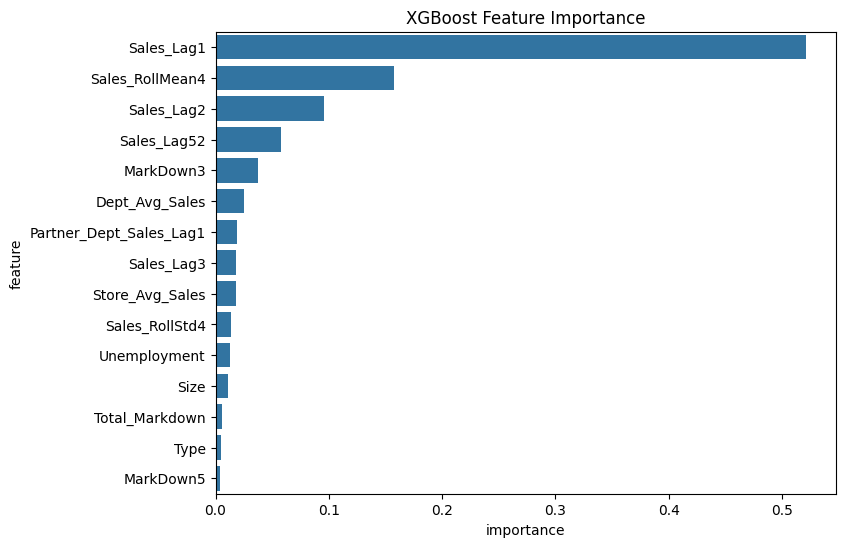

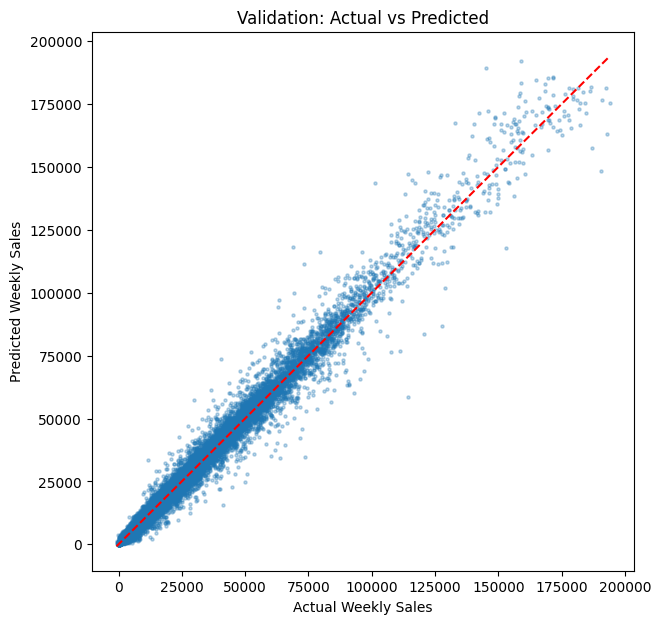

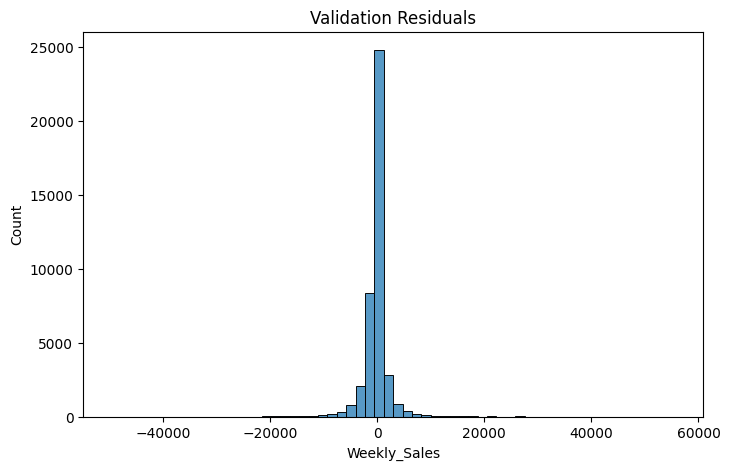

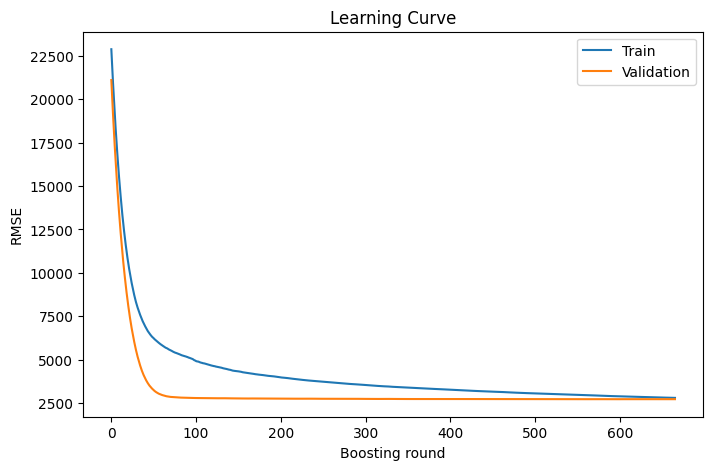

train_mae,▁
train_r2,▁
train_rmse,▁
train_wmae,▁
val_mae,▁
val_r2,▁
val_rmse,▁
val_wmae,▁
train_mae,1361.74912
train_r2,0.985
train_rmse,2792.8306


XGBoost_Training run finished


In [15]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

run = wandb.init(project="walmart-sales-forecasting", group="XGBoost_Training",
                  name="XGBoost_Training", job_type="training", config=best_params)

final_model = xgb.XGBRegressor(objective="reg:squarederror",
                                random_state=42, n_jobs=-1, tree_method="hist",
                                early_stopping_rounds=50, **best_params)
final_model.fit(X_train, y_train, sample_weight=w_train,
                 eval_set=[(X_train, y_train), (X_val, y_val)],
                 sample_weight_eval_set=[w_train, w_val], verbose=100)

train_pred = final_model.predict(X_train)
val_pred   = final_model.predict(X_val)

metrics = {
    "train_wmae": weighted_mae(y_train, train_pred, w_train),
    "val_wmae":   weighted_mae(y_val, val_pred, w_val),
    "train_mae":  mean_absolute_error(y_train, train_pred),
    "val_mae":    mean_absolute_error(y_val, val_pred),
    "train_rmse": np.sqrt(mean_squared_error(y_train, train_pred)),
    "val_rmse":   np.sqrt(mean_squared_error(y_val, val_pred)),
    "train_r2":   r2_score(y_train, train_pred),
    "val_r2":     r2_score(y_val, val_pred),
}
wandb.log(metrics)
print(metrics)

importance_df = pd.DataFrame({"feature": feature_cols,
                               "importance": final_model.feature_importances_}
                              ).sort_values("importance", ascending=False)
wandb.log({"feature_importance": wandb.Table(dataframe=importance_df)})

plt.figure(figsize=(8, 6))
sns.barplot(x="importance", y="feature", data=importance_df)
plt.title("XGBoost Feature Importance")
wandb.log({"Feature_Importance_Plot": wandb.Image(plt)})
plt.show()
plt.close()

plt.figure(figsize=(7, 7))
plt.scatter(y_val, val_pred, alpha=0.3, s=5)
plt.plot([y_val.min(), y_val.max()], [y_val.min(), y_val.max()], 'r--')
plt.xlabel("Actual Weekly Sales"); plt.ylabel("Predicted Weekly Sales")
plt.title("Validation: Actual vs Predicted")
wandb.log({"Actual_vs_Predicted": wandb.Image(plt)})
plt.show()
plt.close()

residuals = y_val - val_pred
plt.figure(figsize=(8, 5))
sns.histplot(residuals, bins=60)
plt.title("Validation Residuals")
wandb.log({"Residuals_Distribution": wandb.Image(plt)})
plt.show()
plt.close()

evals = final_model.evals_result()
plt.figure(figsize=(8, 5))
plt.plot(evals["validation_0"]["rmse"], label="Train")
plt.plot(evals["validation_1"]["rmse"], label="Validation")
plt.xlabel("Boosting round"); plt.ylabel("RMSE"); plt.legend()
plt.title("Learning Curve")
wandb.log({"Learning_Curve": wandb.Image(plt)})
plt.show()
plt.close()

final_model.save_model("/content/xgboost_final_model.json")
model_artifact = wandb.Artifact(name="xgboost_final_model", type="model",
                                 description=f"Best XGBoost model, val_wmae={metrics['val_wmae']:.2f}")
model_artifact.add_file("/content/xgboost_final_model.json")
wandb.run.log_artifact(model_artifact)

wandb.finish()
print("XGBoost_Training run finished")

## Section 15 — Feature Count Sweep (Walk-Forward CV Averaged)

k=4: cv_mean_wmae=1786.09 (+/-468.60)
k=6: cv_mean_wmae=1714.65 (+/-405.81)
k=8: cv_mean_wmae=1591.56 (+/-393.73)
k=12: cv_mean_wmae=1642.09 (+/-442.78)
k=15: cv_mean_wmae=1541.50 (+/-309.46)
k=20: cv_mean_wmae=1537.68 (+/-296.77)
k=30: cv_mean_wmae=1442.29 (+/-272.09)
k=32: cv_mean_wmae=1442.29 (+/-272.09)


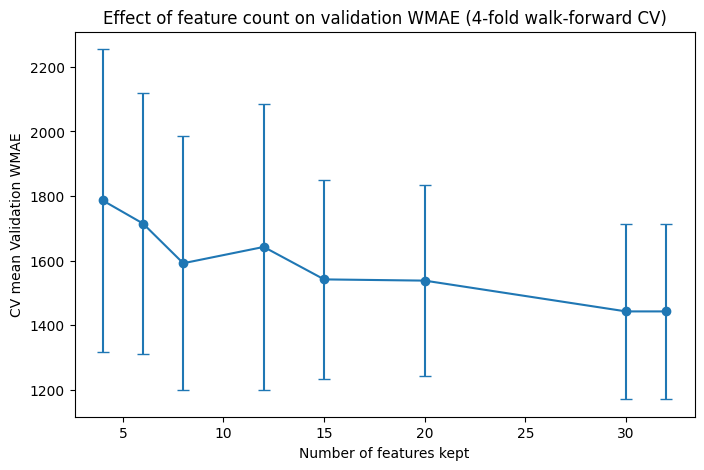


Best k: 30


In [16]:
run = wandb.init(project="walmart-sales-forecasting", group="XGBoost_Training",
                  name="XGBoost_Feature_Count_Sweep", job_type="feature-experiment",
                  config={"validation": "4-fold walk-forward CV"})

k_values = [4, 6, 8, 12, 15, 20, 30, len(candidate_features)]  # last one = all candidates
sweep_results = []

for k in k_values:
    feats_k = selection_df.head(k).index.tolist()

    fold_wmaes = []
    for train_fold, val_fold in prepared_cv_folds:
        Xtr, ytr = train_fold[feats_k], train_fold['Weekly_Sales']
        Xva, yva = val_fold[feats_k],   val_fold['Weekly_Sales']
        wtr = np.where(train_fold['IsHoliday'] == 1, 5, 1)
        wva = np.where(val_fold['IsHoliday'] == 1, 5, 1)

        m = xgb.XGBRegressor(objective="reg:squarederror", random_state=42, n_jobs=-1,
                              tree_method="hist", early_stopping_rounds=50, **best_params)
        m.fit(Xtr, ytr, sample_weight=wtr, eval_set=[(Xva, yva)], sample_weight_eval_set=[wva], verbose=False)
        fold_wmaes.append(weighted_mae(yva, m.predict(Xva), wva))

    mean_wmae = float(np.mean(fold_wmaes))
    std_wmae  = float(np.std(fold_wmaes))
    sweep_results.append({"k_features": k, "cv_mean_wmae": mean_wmae, "cv_std_wmae": std_wmae})
    print(f"k={k}: cv_mean_wmae={mean_wmae:.2f} (+/-{std_wmae:.2f})")

sweep_df = pd.DataFrame(sweep_results)
wandb.log({"feature_count_sweep": wandb.Table(dataframe=sweep_df)})

plt.figure(figsize=(8, 5))
plt.errorbar(sweep_df['k_features'], sweep_df['cv_mean_wmae'], yerr=sweep_df['cv_std_wmae'],
             marker='o', capsize=4)
plt.xlabel("Number of features kept"); plt.ylabel("CV mean Validation WMAE")
plt.title("Effect of feature count on validation WMAE (4-fold walk-forward CV)")
wandb.log({"Feature_Count_Sweep_Plot": wandb.Image(plt)})
plt.show(); plt.close()

best_k = int(sweep_df.loc[sweep_df['cv_mean_wmae'].idxmin(), 'k_features'])
print(f"\nBest k: {best_k}")
wandb.finish()

## Section 16 — Final Model (All Features)

[0]	validation_0-rmse:22855.20045	validation_1-rmse:21111.71738
[100]	validation_0-rmse:3374.48121	validation_1-rmse:2636.03816
[200]	validation_0-rmse:2792.13914	validation_1-rmse:2568.19333
[300]	validation_0-rmse:2528.14516	validation_1-rmse:2532.00204
[400]	validation_0-rmse:2343.21625	validation_1-rmse:2518.49581
[466]	validation_0-rmse:2253.33814	validation_1-rmse:2516.82489
{'train_wmae': np.float64(1207.601034478219), 'val_wmae': np.float64(1232.409117385868), 'train_r2': 0.9888996573734073, 'val_r2': 0.9883414234760571}


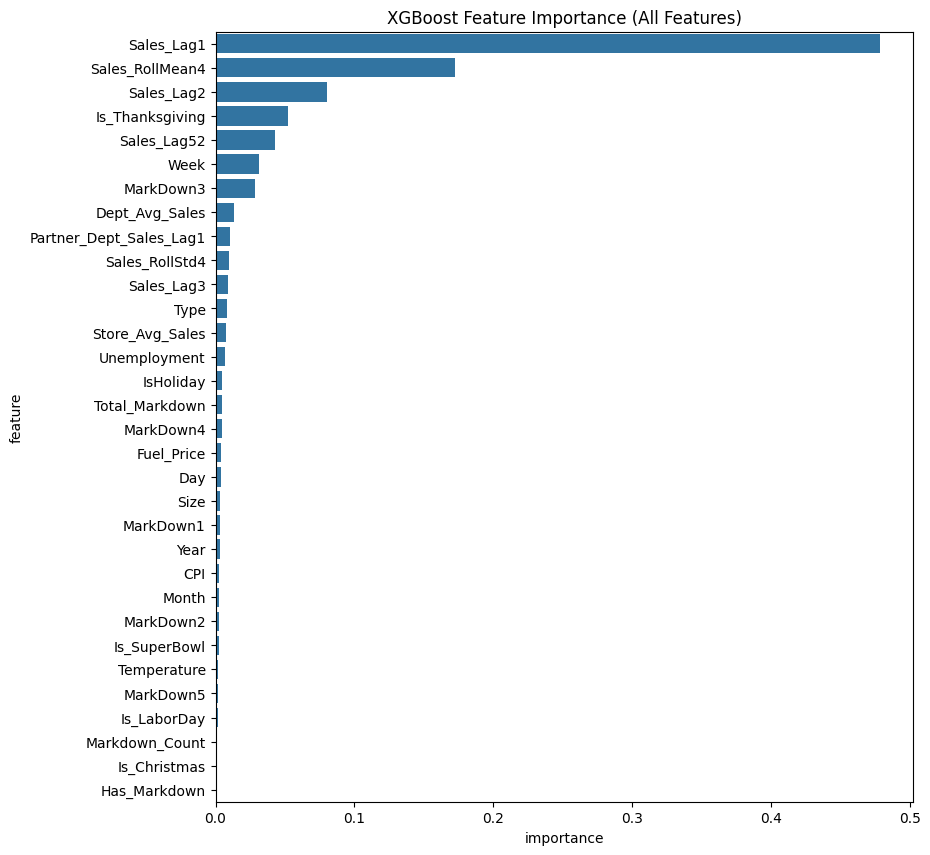

train_r2,▁
train_wmae,▁
val_r2,▁
val_wmae,▁
train_r2,0.9889
train_wmae,1207.60103
val_r2,0.98834
val_wmae,1232.40912


XGBoost_Training_Final run finished


In [17]:
run = wandb.init(project="walmart-sales-forecasting", group="XGBoost_Training",
                  name="XGBoost_Training_Final", job_type="training",
                  config={**best_params, "feature_set": "all_candidates", "n_features": len(candidate_features)})

final_feature_cols = candidate_features

X_train, y_train = train_df[final_feature_cols], train_df['Weekly_Sales']
X_val, y_val     = val_df[final_feature_cols],   val_df['Weekly_Sales']
w_train = np.where(train_df['IsHoliday'] == 1, 5, 1)
w_val   = np.where(val_df['IsHoliday'] == 1, 5, 1)

final_model = xgb.XGBRegressor(objective="reg:squarederror",
                                random_state=42, n_jobs=-1, tree_method="hist",
                                early_stopping_rounds=50, **best_params)
final_model.fit(X_train, y_train, sample_weight=w_train,
                 eval_set=[(X_train, y_train), (X_val, y_val)],
                 sample_weight_eval_set=[w_train, w_val], verbose=100)

train_pred = final_model.predict(X_train)
val_pred   = final_model.predict(X_val)

metrics = {
    "train_wmae": weighted_mae(y_train, train_pred, w_train),
    "val_wmae":   weighted_mae(y_val, val_pred, w_val),
    "train_r2":   r2_score(y_train, train_pred),
    "val_r2":     r2_score(y_val, val_pred),
}
wandb.log(metrics)
print(metrics)

importance_df = pd.DataFrame({"feature": final_feature_cols,
                               "importance": final_model.feature_importances_}
                              ).sort_values("importance", ascending=False)
wandb.log({"feature_importance": wandb.Table(dataframe=importance_df)})

plt.figure(figsize=(9, 10))
sns.barplot(x="importance", y="feature", data=importance_df)
plt.title("XGBoost Feature Importance (All Features)")
wandb.log({"Feature_Importance_Plot": wandb.Image(plt)})
plt.show()
plt.close()

final_model.save_model("/content/xgboost_final_model.json")
model_artifact = wandb.Artifact(name="xgboost_final_model", type="model",
                                 description=f"Final model, all {len(final_feature_cols)} features, val_wmae={metrics['val_wmae']:.2f}")
model_artifact.add_file("/content/xgboost_final_model.json")
wandb.run.log_artifact(model_artifact)

wandb.finish()
print("XGBoost_Training_Final run finished")

## Section 17 — Full Inference Pipeline (Preprocessing + Model)

In [18]:
class XGBoostFullPipeline:
    """
    Combines the preprocessing pipeline and the trained model into one object.
    .predict(raw_df, stores_df, features_df) takes RAW, unprocessed data
    (same schema as train.csv/test.csv) and returns Weekly_Sales predictions
    directly -- no manual intermediate steps required.
    """

    def __init__(self, preprocessing_pipeline, model, feature_cols):
        self.preprocessing_pipeline = preprocessing_pipeline
        self.model = model
        self.feature_cols = feature_cols

    def predict(self, raw_df, stores_df, features_df):
        engineered = self.preprocessing_pipeline.transform(raw_df, stores_df, features_df)
        X = engineered[self.feature_cols]
        predictions = self.model.predict(X)
        return predictions, engineered


# Rebuild the preprocessing pipeline using the FULL engineered dataset as history
# (not just train_df) -- at real inference time there's no held-out validation
# concern anymore, all labeled data becomes legitimate history for lag features.
full_preprocessing_pipeline = XGBoostPreprocessingPipeline(
    dept_avg_map=dept_avg_map,
    store_avg_map=store_avg_map,
    best_partner=best_partner,
    overall_mean_sales=overall_mean_sales,
    markdown_cols=markdown_cols,
    train_history=df,
)

full_pipeline = XGBoostFullPipeline(
    preprocessing_pipeline=full_preprocessing_pipeline,
    model=final_model,
    feature_cols=final_feature_cols,
)

print("Full pipeline built. Usage: full_pipeline.predict(raw_df, stores, features)")

Full pipeline built. Usage: full_pipeline.predict(raw_df, stores, features)


In [19]:
# Sanity check: load RAW files fresh (never touched by any cleaning/engineering)
# and confirm the full pipeline works end-to-end on genuinely raw input
raw_path = '/content/drive/MyDrive/ML-final/data/raw/'
raw_train = pd.read_csv(raw_path + 'train.csv')
raw_stores = pd.read_csv(raw_path + 'stores.csv')
raw_features = pd.read_csv(raw_path + 'features.csv')

raw_sample = raw_train[(raw_train['Store'] == 1) & (raw_train['Dept'] == 1)].iloc[100:120].copy()

preds, _ = full_pipeline.predict(raw_sample, raw_stores, raw_features)
check_df = pd.DataFrame({
    "Store": raw_sample['Store'].values, "Dept": raw_sample['Dept'].values,
    "Date": raw_sample['Date'].values,
    "Actual": raw_sample['Weekly_Sales'].values, "Predicted": preds
})
print(check_df)

    Store  Dept        Date    Actual     Predicted
0       1     1  2012-01-06  16567.69  17177.191406
1       1     1  2012-01-13  16894.40  15993.606445
2       1     1  2012-01-20  18365.10  17148.003906
3       1     1  2012-01-27  18378.16  17956.472656
4       1     1  2012-02-03  23510.49  21716.326172
5       1     1  2012-02-10  36988.49  35381.394531
6       1     1  2012-02-17  54060.10  49792.792969
7       1     1  2012-02-24  20124.22  23410.830078
8       1     1  2012-03-02  20113.03  19485.328125
9       1     1  2012-03-09  21140.07  21648.634766
10      1     1  2012-03-16  22366.88  24697.296875
11      1     1  2012-03-23  22107.70  21624.759766
12      1     1  2012-03-30  28952.86  22160.150391
13      1     1  2012-04-06  57592.12  32354.169922
14      1     1  2012-04-13  34684.21  35991.265625
15      1     1  2012-04-20  16976.19  21881.671875
16      1     1  2012-04-27  16347.60  20155.419922
17      1     1  2012-05-04  17147.44  18531.763672
18      1   

In [20]:
run = wandb.init(project="walmart-sales-forecasting", group="XGBoost_Training",
                  name="XGBoost_Full_Pipeline_Save", job_type="pipeline-export")

import pickle
with open("/content/xgboost_full_pipeline.pkl", "wb") as f:
    pickle.dump(full_pipeline, f)

pipeline_artifact = wandb.Artifact(
    name="xgboost_full_pipeline", type="model",
    description=f"Complete preprocessing+model pipeline, runs directly on raw data. val_wmae={metrics['val_wmae']:.2f}"
)
pipeline_artifact.add_file("/content/xgboost_full_pipeline.pkl")
wandb.run.log_artifact(pipeline_artifact)

wandb.finish()
print("Full pipeline saved and logged as xgboost_full_pipeline")

Full pipeline saved and logged as xgboost_full_pipeline
